In [ ]:
# Xin: set Historical_emissions = 355.558 to fits the previouse report
def Lordetal_sfts02(scenario='SSP5-85',allEmissions=4758.780527631557):
    # Lordetal_sfts02
    #
    #   ***********************************************************************
    #   *** CONVOLUTED RESPONSE FUNCTION **************************************
    #   ***********************************************************************
    #
    #   Calculates the atmospheric decay over time of time-dependent CO2 
    #   emissions*. 
    #
    #           *Calculates CO2 decay as a series of separate yearly pulse
    #           emissions, with the cubic fitting coefficients scaled to the
    #           total cumulative future emissions. The CO2 perturbations above
    #           pre-industrial  are then summed to give the progressive
    #           increase in atmospheric CO2 over the emissions period.
    #
    #   1) "Time" and "CO2" vectors will be loaded into Python Workspace.
    #
    #   2) Plots CO2 over time.
    #
    #   3) Combines "Time" and "CO2" vectors into a single matrix and saves to
    #   a tab-delimited text file called "CO2_data.txt".
    #
    #   ***********************************************************************
    #   *** HISTORY ***********************************************************
    #   ***********************************************************************
    #
    #   15/06/03: Created
    #
    #   ***********************************************************************
    #   *** TO RUN ************************************************************
    #   ***********************************************************************
    #
    #   > Create text file containing time-series of required saving
    #   points that covers the required length of the experiment. Ensure all
    #   individual years in which emissions are released (i.e. in
    #   "CO2_emissions.txt") are included.
    #
    #       e.g. For 1 Ma :    
    #
    #                           % Time (yr)
    #                           1
    #                           2
    #                           3
    #                           .
    #                           .
    #                           980000
    #                           1000000
    #
    #           - Save it as "Time.txt" (as in line 101 of 
    #           Lordetal_sfts02.py file).
    #           - Alternatively, use the example 1 Myr time-series that has  
    #           been provided as Supplementary Information
    #           (Lordetal_sfts03_Time_example.txt).
    #   
    #   > Create tab/space-delimited text file containing time-series of annual
    #   future CO2 emissions (column 2 - in PgC) over time (column 1 - in yr).
    #
    #       e.g. For increasing emissions that stop after 5 years :
    #
    #                           % Time (yr)    Emissions (PgC yr-1)
    #                           1               2
    #                           2               4
    #                           3               6
    #                           4               8
    #                           5               10
    #                           6               0
    #
    #           - Save it as "CO2_emissions.txt" (as in line 103 of
    #           Lordetal_sfts02.py file).
    # 
    #   > In Lordetal_sfts02.py file:
    #
    #           - Set "Future_emissions" variable (line 105) to required  
    #           total future CO2 emissions (i.e. sum of annual emissions from  
    #           'CO2_emissions.txt' - in PgC), e.g. 30 in above example and as 
    #           below.
    #
    #           - Set "Historical_emissions" variable (line 107) to required 
    #           historical emissions (in PgC). Leave as 0 if not required (as
    #           below).
    #
    #   > In iPython console, type: "CO2_timeseries = Lordetal_sfts02()"
    #
    #   ***********************************************************************
    
    
    # *********************************************************************** #
    # *** IMPORT REQUIRED PACKAGES ****************************************** #
    # *********************************************************************** #
    #
    import numpy as np
    import matplotlib.pyplot as plt
    #
    # *********************************************************************** #
    
    # *********************************************************************** #
    # *** SET UP CUBIC MODEL ************************************************ #
    # *********************************************************************** #
    #
    Time = np.loadtxt("Time.txt", dtype=float, comments="%", skiprows=0)    # Import time-series data
    #
    Future_emissions_timeseries = np.loadtxt("SSP/CO2_emissions_" + scenario + ".txt", dtype=float, comments="#", skiprows=0)    # Import emissions time-series data
    #
    Future_emissions = np.array([allEmissions], dtype=float)    # Total future CO2 emissions (PgC)
    #157.2594447803
    Historical_emissions = 283.962 #355.558    # Total historical CO2 emissions (PgC)
    #
    # Set up variables
    #
    t = Time    # Time
    t0 = t[0]    # Time from start of decay curve (i.e. year 1)
    B = 278    # Baseline CO2 (ppmv)
    E_future_nonzero = sum(Future_emissions_timeseries[:,1] > 0)    # Calculate total number of years in emissions period
    E_future = np.array(Future_emissions_timeseries[0:E_future_nonzero,1] * 0.469)    # Future CO2 emissions timeseries (ppmv)
    E_historical = np.array(Historical_emissions * 0.469)    # Total historical CO2 emissions (ppmv)
    uE_future = np.array(Future_emissions, dtype=float)    # Total future CO2 emissions (PgC)
    uE2_future = np.power(uE_future,2)    # Total future CO2 emissions squared (PgC)
    uE3_future = np.power(uE_future,3)    # Total future CO2 emissions cubed (PgC)
    uE_historical = np.array(Historical_emissions, dtype=float)    # % Total historical CO2 emissions (PgC)
    uE2_historical = np.power(uE_historical,2)    # Total historical CO2 emissions squared (PgC)
    uE3_historical = np.power(uE_historical,3)    # Total historical CO2 emissions cubed (PgC)
    #
    t_length = len(t)    # Calculate total number of time-series saving points
    E_future_length = len(E_future)    # Calculate total number of emissions scenarios
    co2 = np.zeros((t_length,1), dtype=float)    # Set-up CO2 (total) variable for use in response function to required dimensions
    co2_historical = np.zeros((t_length,1), dtype=float)    # Set-up CO2 (historical) variable to required dimensions
    co2_future = np.zeros((t_length,E_future_length), dtype=float)    # Set-up CO2 (future annual) variable to required dimensions (decay of CO2 released in each year calculated in a separate column)
    co2_future_sum = np.zeros((t_length,1), dtype=float)    # Set-up CO2 (total future) variable for use in response function to required dimensions (annual decay curves from above summed)
    #
    # Load cubic fitting coefficients
    #
    alpha_i = np.array([0.253, 0.2449, 0.312, 0.079, 0.0748])    # y-intercept on A_i axis
    beta1_i = np.array([-4.6275e-05, -3.5401e-05, 4.9956e-05, 3.9591e-05, -8.5717e-07])
    beta2_i = np.array([3.4435e-09, 2.3961e-09, -5.8703e-09, -4.8312e-10, 5.8912e-11])
    beta3_i = np.array([-8.4182e-14, -5.5658e-14, 1.6524e-13, -1.4607e-14, -1.1465e-15])
    #
    gamma_i = np.array([6.2818, 58.6823, 112.582, 2779.9, 246294.0])    # y-intercept on tau_i axis
    delta1_i = np.array([-1.0495e-03, -2.9881e-03, 0.1214, 0.8163, 0.4499])
    delta2_i = np.array([6.8958e-08, 6.1496e-08, -7.8699e-06, 6.2865e-06, 2.5469e-04])
    delta3_i = np.array([-1.4906e-12, 1.6891e-12, 1.8612e-10, -7.2684e-10, -9.6876e-09])
    #
    # *********************************************************************** #
    
    # *********************************************************************** #
    # *** RUN CUBIC MODEL**************************************************** #
    # *********************************************************************** #
    #
    # Historical emissions (pulse)
    #
    co2_historical[:,0] = B + E_historical * (
        (alpha_i[0] + beta1_i[0]*uE_historical + beta2_i[0]*uE2_historical + beta3_i[0]*uE3_historical) *np.exp(-(t-t0) / (gamma_i[0] + delta1_i[0]*uE_historical + delta2_i[0]*uE2_historical + delta3_i[0]*uE3_historical)) +
        (alpha_i[1] + beta1_i[1]*uE_historical + beta2_i[1]*uE2_historical + beta3_i[1]*uE3_historical) *np.exp(-(t-t0) / (gamma_i[1] + delta1_i[1]*uE_historical + delta2_i[1]*uE2_historical + delta3_i[1]*uE3_historical)) +
        (alpha_i[2] + beta1_i[2]*uE_historical + beta2_i[2]*uE2_historical + beta3_i[2]*uE3_historical) *np.exp(-(t-t0) / (gamma_i[2] + delta1_i[2]*uE_historical + delta2_i[2]*uE2_historical + delta3_i[2]*uE3_historical)) +
        (alpha_i[3] + beta1_i[3]*uE_historical + beta2_i[3]*uE2_historical + beta3_i[3]*uE3_historical) *np.exp(-(t-t0) / (gamma_i[3] + delta1_i[3]*uE_historical + delta2_i[3]*uE2_historical + delta3_i[3]*uE3_historical)) +
        (alpha_i[4] + beta1_i[4]*uE_historical + beta2_i[4]*uE2_historical + beta3_i[4]*uE3_historical) *np.exp(-(t-t0) / (gamma_i[4] + delta1_i[4]*uE_historical + delta2_i[4]*uE2_historical + delta3_i[4]*uE3_historical)))
    #
    # Future emissions (convolution)
    #
    for j in range (0, 1):
        for k in range (0, E_future_length):
            co2_future[k:-1,k] = E_future[k] * (
                (alpha_i[0] + beta1_i[0]*uE_future[j] + beta2_i[0]*uE2_future[j] + beta3_i[0]*uE3_future[j]) *np.exp(-(t[k:-1]-t[k]) / (gamma_i[0] + delta1_i[0]*uE_future[j] + delta2_i[0]*uE2_future[j] + delta3_i[0]*uE3_future[j])) +
                (alpha_i[1] + beta1_i[1]*uE_future[j] + beta2_i[1]*uE2_future[j] + beta3_i[1]*uE3_future[j]) *np.exp(-(t[k:-1]-t[k]) / (gamma_i[1] + delta1_i[1]*uE_future[j] + delta2_i[1]*uE2_future[j] + delta3_i[1]*uE3_future[j])) +
                (alpha_i[2] + beta1_i[2]*uE_future[j] + beta2_i[2]*uE2_future[j] + beta3_i[2]*uE3_future[j]) *np.exp(-(t[k:-1]-t[k]) / (gamma_i[2] + delta1_i[2]*uE_future[j] + delta2_i[2]*uE2_future[j] + delta3_i[2]*uE3_future[j])) +
                (alpha_i[3] + beta1_i[3]*uE_future[j] + beta2_i[3]*uE2_future[j] + beta3_i[3]*uE3_future[j]) *np.exp(-(t[k:-1]-t[k]) / (gamma_i[3] + delta1_i[3]*uE_future[j] + delta2_i[3]*uE2_future[j] + delta3_i[3]*uE3_future[j])) +
                (alpha_i[4] + beta1_i[4]*uE_future[j] + beta2_i[4]*uE2_future[j] + beta3_i[4]*uE3_future[j]) *np.exp(-(t[k:-1]-t[k]) / (gamma_i[4] + delta1_i[4]*uE_future[j] + delta2_i[4]*uE2_future[j] + delta3_i[4]*uE3_future[j])))
        co2_future_sum = np.sum(co2_future, axis = 1, keepdims = True)
        co2 = co2_future_sum + co2_historical
    #
    # *********************************************************************** #
    
    # *********************************************************************** #
    # *** PLOT DATA ********************************************************* #
    # *********************************************************************** #
    #
    plt.figure()
    for j in range (0, 1):
        plt.semilogx(Time[:], co2[:,j])
        # plt.plot(Time[:], co2[:,j])
    plt.xlabel('Year')
    plt.ylabel('Atmoshperic CO$_2$ (ppmv)')   
    plt.xlim(min(Time), max(Time))
    plt.ylim(0, 1.1*max(co2[:,j]))
    #
    # *********************************************************************** #
    
    # *********************************************************************** #
    # *** SAVE DATA ********************************************************* #
    # *********************************************************************** #
    #
    co2_timeseries = np.column_stack((Time, co2))
    co2_text = '% Time / CO2 (ppmv)'
    #
    np.savetxt('SSP/concentration_ppmv/CO2_' + scenario + '_ppmv.txt', co2_timeseries, fmt = '%.6g', delimiter = '\t', newline = '\n', header = co2_text)
    #
    print(f'file be saved at SSP/concentration_ppmv/CO2_' + scenario + '_ppmv.txt')
    print(co2_timeseries)
    return co2_timeseries    
    #
    # *********************************************************************** #
    
    # *********************************************************************** #
    # *** END *************************************************************** #

perform the code

/var/folders/31/lmwyg8_x08j0p9p16_pnmtmr0000gp/T/ipykernel_95312/2930296828.py:184: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  plt.xlim(min(Time), max(Time))


file be saved at CO2_SSP1-26_ppmv.txt
[[0.00000000e+00 4.10274907e+02]
 [1.00000000e+00 4.08126716e+02]
 [2.00000000e+00 4.06698501e+02]
 ...
 [9.99000000e+05 2.78433857e+02]
 [1.00000000e+06 2.78432100e+02]
 [1.00100000e+06 2.78170973e+02]]
file be saved at CO2_SSP2-45_ppmv.txt
[[0.00000000e+00 4.10298768e+02]
 [1.00000000e+00 4.08183125e+02]
 [2.00000000e+00 4.06799227e+02]
 ...
 [9.99000000e+05 2.79041556e+02]
 [1.00000000e+06 2.79037353e+02]
 [1.00100000e+06 2.78170973e+02]]
file be saved at CO2_SSP3-70_ppmv.txt
[[0.00000000e+00 4.10338174e+02]
 [1.00000000e+00 4.08279545e+02]
 [2.00000000e+00 4.06979824e+02]
 ...
 [9.99000000e+05 2.80617537e+02]
 [1.00000000e+06 2.80607126e+02]
 [1.00100000e+06 2.78170973e+02]]
file be saved at CO2_SSP5-85_ppmv.txt
[[0.00000000e+00 4.10365295e+02]
 [1.00000000e+00 4.08342562e+02]
 [2.00000000e+00 4.07094460e+02]
 ...
 [9.99000000e+05 2.81884729e+02]
 [1.00000000e+06 2.81869500e+02]
 [1.00100000e+06 2.78170973e+02]]
file be saved at CO2_10000pgc_pp

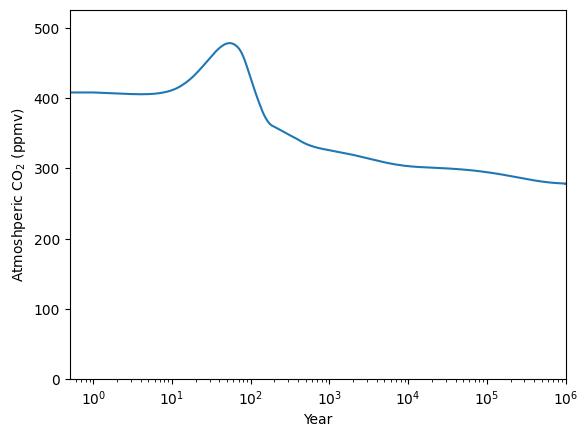

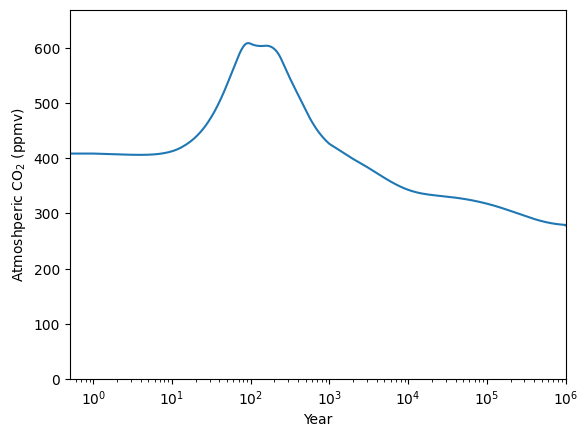

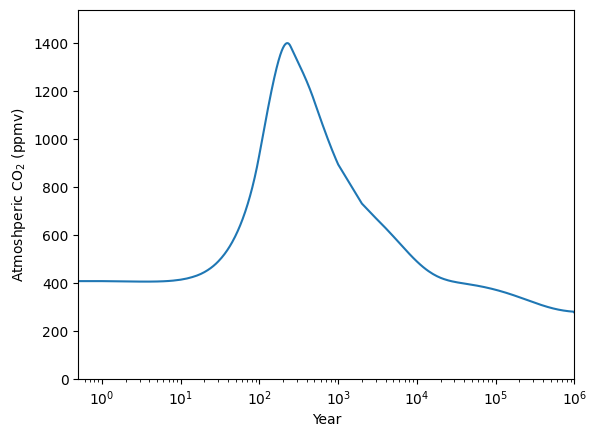

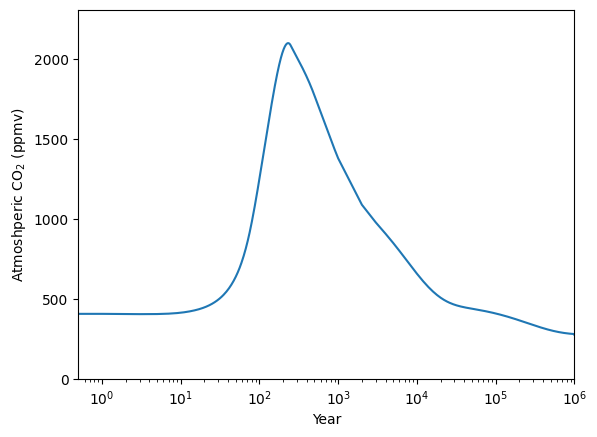

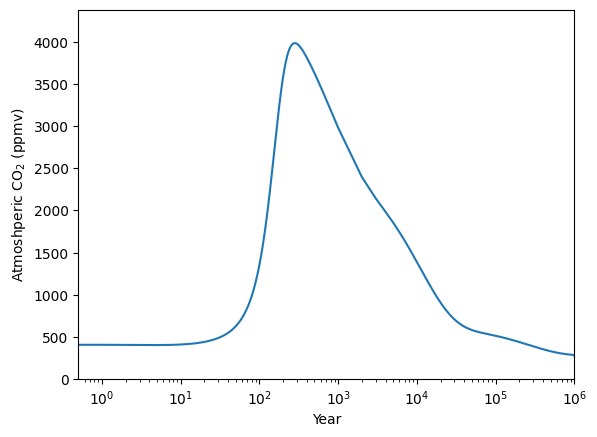

In [4]:
# CO2_timeseries = Lordetal_sfts02(scenario='RCP85', allEmissions=5424.735651)  # Call the function to get CO2 timeseries
# CO2_timeseries = Lordetal_sfts02(scenario='RCP45', allEmissions=1258.03644997)  # Call the function to get CO2 timeseries
# CO2_timeseries = Lordetal_sfts02(scenario='SSP1-19', allEmissions=100.79776096472912)  # Call the function to get CO2 timeseries
CO2_timeseries = Lordetal_sfts02(scenario='SSP1-26', allEmissions=430.6680414657644)  # Call the function to get CO2 timeseries
CO2_timeseries = Lordetal_sfts02(scenario='SSP2-45', allEmissions=1421.1473173309819)  # Call the function to get CO2 timeseries
CO2_timeseries = Lordetal_sfts02(scenario='SSP3-70', allEmissions=3839.069952723064)  # Call the function to get CO2 timeseries
# CO2_timeseries = Lordetal_sfts02(scenario='SSP4-60', allEmissions=1882.0937216894627)  # Call the function to get CO2 timeseries
# CO2_timeseries = Lordetal_sfts02(scenario='SSP5-34', allEmissions=461.6533124343855)  # Call the function to get CO2 timeseries
CO2_timeseries = Lordetal_sfts02(scenario='SSP5-85', allEmissions=5549.204141174261)  # Call the function to get CO2 timeseries
CO2_timeseries = Lordetal_sfts02(scenario='10000pgc', allEmissions=10000)  # Call the function to get CO2 timeseries
# CO2_timeseries = Lordetal_sfts02(scenario='natural', allEmissions=0)  # Call the function to get CO2 timeseries
# ssp5-85 sum emissions withour permafrost: 4900.012449294129
# ssp5-34 sum emissions withour permafrost: 321.9522768071693
# ssp4-60 sum emissions withour permafrost: 1554.233819799227
# ssp3-70 sum emissions withour permafrost: 3332.2272229518157
# ssp2-45 sum emissions withour permafrost: 1195.2647853747567
# ssp1-26 sum emissions withour permafrost: 326.6990264011347
# ssp1-19 sum emissions withour permafrost: 32.04764074408925

# Total Accumulated Emissions SSP5-8.5 from 2000 to 2500: 5549.204141174261
# Total Accumulated Emissions SSP5-3.4 from 2000 to 2500: 461.6533124343855
# Total Accumulated Emissions SSP4-6.0 from 2000 to 2500: 1882.0937216894627
# Total Accumulated Emissions SSP3-7.0 from 2000 to 2500: 3839.069952723064
# Total Accumulated Emissions SSP2-4.5 from 2000 to 2500: 1421.1473173309819
# Total Accumulated Emissions SSP1-2.6 from 2000 to 2500: 430.6680414657644
# Total Accumulated Emissions SSP1-1.9 from 2000 to 2500: 100.79776096472912